# Nama: Shabbir Fazle Mawla Yudhistira
# NIM: 25/566451/PA/23909
# PCD_Assignment02

In [82]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Input Image

In [83]:
gambar = Image.open("images/astronaut.png").convert("L")
matriksblur = np.array(gambar)

## Blur Image Enhancement

In [84]:
def tetangga4(x, y, matriks):
    atas = int(matriks[y-1][x])
    bawah = int(matriks[y+1][x])
    kiri = int(matriks[y][x-1])
    kanan = int(matriks[y][x+1])
    return atas + bawah + kiri + kanan

def tetangga8(x, y, matriks):
    atas_kiri = int(matriks[y-1][x-1])
    atas = int(matriks[y-1][x])
    atas_kanan = int(matriks[y-1][x+1])
    kiri = int(matriks[y][x-1])
    kanan = int(matriks[y][x+1])
    bawah_kiri = int(matriks[y+1][x-1])
    bawah = int(matriks[y+1][x])
    bawah_kanan = int(matriks[y+1][x+1])
    return atas_kiri + atas + atas_kanan + kiri + kanan + bawah_kiri + bawah + bawah_kanan

def bluring(x, y):
    tengah = int(matriksblur[y][x])
    mean_matriks = (tengah + tetangga8(x, y, matriksblur)) / 9
    tengah = mean_matriks
    return tengah

In [85]:
alpha = [0.5, 1, 1.5, 2]
def lap_sharp4 (x, y, matriks):
    tengah = int(matriks[y][x])
    perubahan = 4 * tengah - tetangga4(x, y, matriks)
    hasil = []
    for i in alpha:
        perubahan_baru = perubahan * i
        piksel_baru = tengah + perubahan_baru
        piksel_baru = max(0, min(255, piksel_baru))
        hasil.append(piksel_baru)
    return hasil

def lap_sharp8 (x, y, matriks):
    tengah = int(matriks[y][x])
    perubahan = 8 * tengah - tetangga8(x, y, matriks)
    hasil = []
    for i in alpha:
        perubahan_baru = perubahan * i
        piksel_baru = tengah + perubahan_baru
        piksel_baru = max(0, min(255, piksel_baru))
        hasil.append(piksel_baru)
    return hasil

In [86]:
hasil_gambar = matriksblur.copy()
for i in range(1, len(matriksblur) - 1):
    for j in range(1, len(matriksblur[i]) - 1):
        hasil = bluring(j, i)
        hasil_gambar[i][j] = hasil

In [87]:
hasil_laplacian4 = [
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy()
]
hasil_laplacian8 = [
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy(),
    hasil_gambar.astype(float).copy()
]

In [88]:
for i in range(1, len(hasil_gambar) - 1):
    for j in range(1, len(hasil_gambar[i]) - 1):
        hasil = lap_sharp4(j, i, hasil_gambar)
        for k in range(len(alpha)):
            hasil_laplacian4[k][i][j] = hasil[k]

for i in range(1, len(hasil_gambar) - 1):
    for j in range(1, len(hasil_gambar[i]) - 1):
        hasil = lap_sharp8(j, i, hasil_gambar)
        for k in range(len(alpha)):
            hasil_laplacian8[k][i][j] = hasil[k]

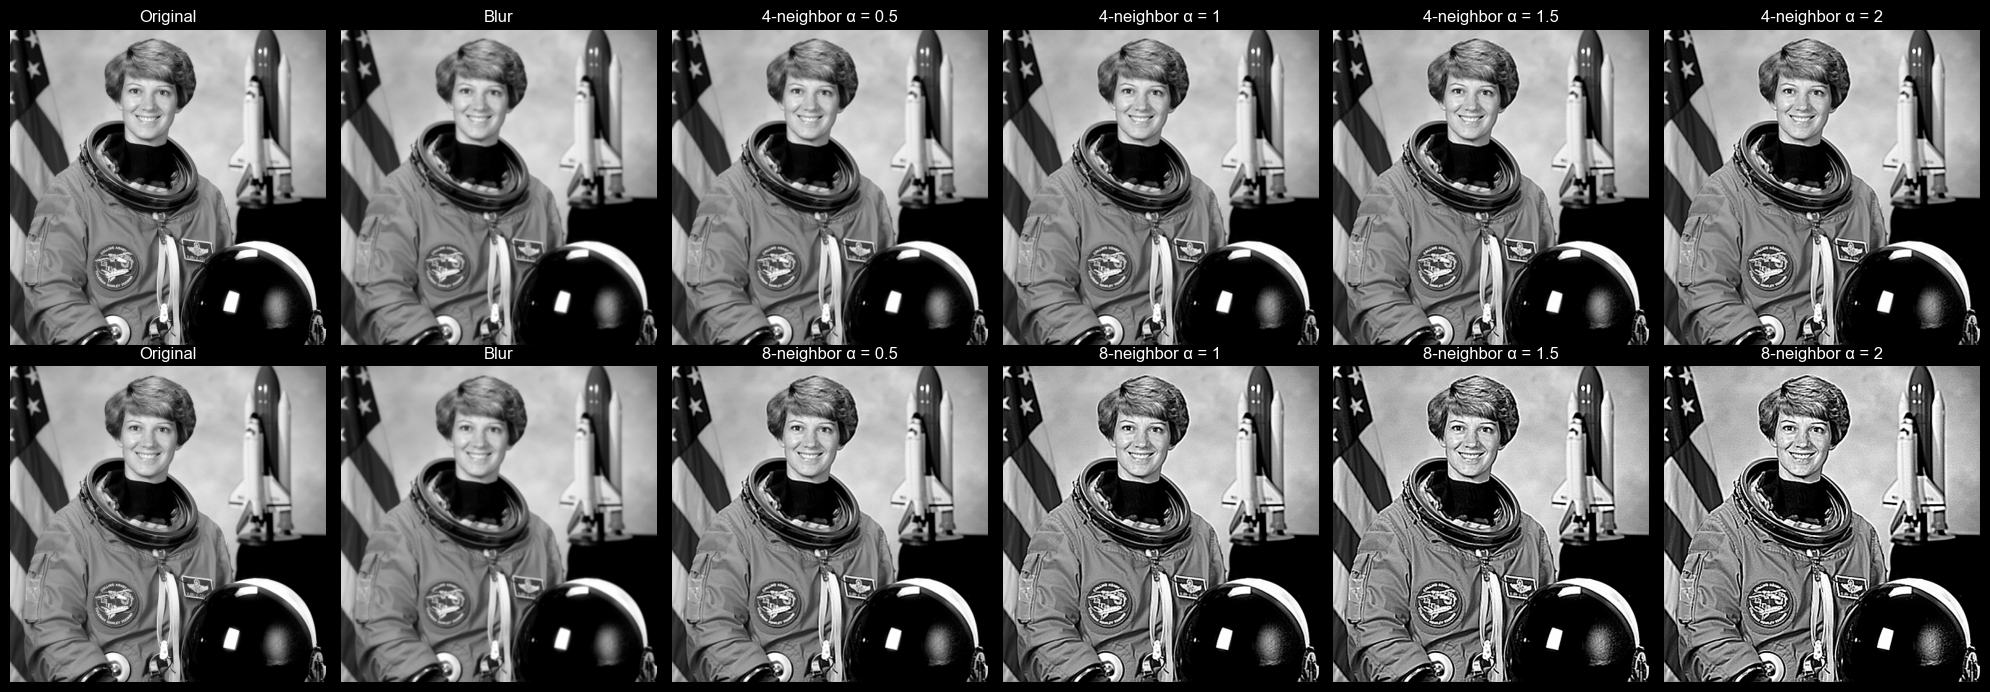

In [89]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

axes[0, 0].imshow(matriksblur, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(hasil_gambar, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Blur")
axes[0, 1].axis("off")

for k in range(len(alpha)):
    axes[0, k + 2].imshow(
        hasil_laplacian4[k],
        cmap="gray",
        vmin=0,
        vmax=255
    )
    axes[0, k + 2].set_title(f"4-neighbor α = {alpha[k]}")
    axes[0, k + 2].axis("off")

axes[1, 0].imshow(matriksblur, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Original")
axes[1, 0].axis("off")


axes[1, 1].imshow(hasil_gambar, cmap="gray", vmin=0, vmax=255)
axes[1, 1].set_title("Blur")
axes[1, 1].axis("off")

for k in range(len(alpha)):
    axes[1, k + 2].imshow(
        hasil_laplacian8[k],
        cmap="gray",
        vmin=0,
        vmax=255
    )
    axes[1, k + 2].set_title(f"8-neighbor α = {alpha[k]}")
    axes[1, k + 2].axis("off")

plt.tight_layout()
plt.show()

## Dark Image Enhancement

In [90]:
gambar_dark = matriksblur.astype(float) * 0.1
gambar_dark = np.clip(gambar_dark, 0, 255)

In [91]:
gambar_dark = gambar_dark.astype(np.uint8)

Image.fromarray(gambar_dark).save("images/dark_image.png")

In [92]:
def log_transform(matriks):
    c = 255 / np.log(1 + 255)
    hasil = matriks.astype(float).copy()
    for i in range(len(matriks)):
        for j in range(len(matriks[i])):
            r = matriks[i][j]
            hasil[i][j] = c * np.log(1 + r)
    return np.clip(hasil, 0, 255).astype(np.uint8)

def histogram_equalization(matriks):
    tinggi = len(matriks)
    lebar = len(matriks[0])
    histogram = [0] * 256
    for i in range(tinggi):
        for j in range(lebar):
            nilai = int(matriks[i][j])
            histogram[nilai] += 1
    cdf = [0] * 256
    cdf[0] = histogram[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + histogram[i]
    cdf_min = 0
    for nilai in cdf:
        if nilai != 0:
            cdf_min = nilai
            break
    total_piksel = tinggi * lebar
    mapping = [0] * 256
    for i in range(256):
        mapping[i] = round(
            ((cdf[i] - cdf_min) /
             (total_piksel - cdf_min)) * 255
        )
    hasil = matriks.copy()
    for i in range(tinggi):
        for j in range(lebar):
            nilai = int(matriks[i][j])
            hasil[i][j] = mapping[nilai]
    return hasil

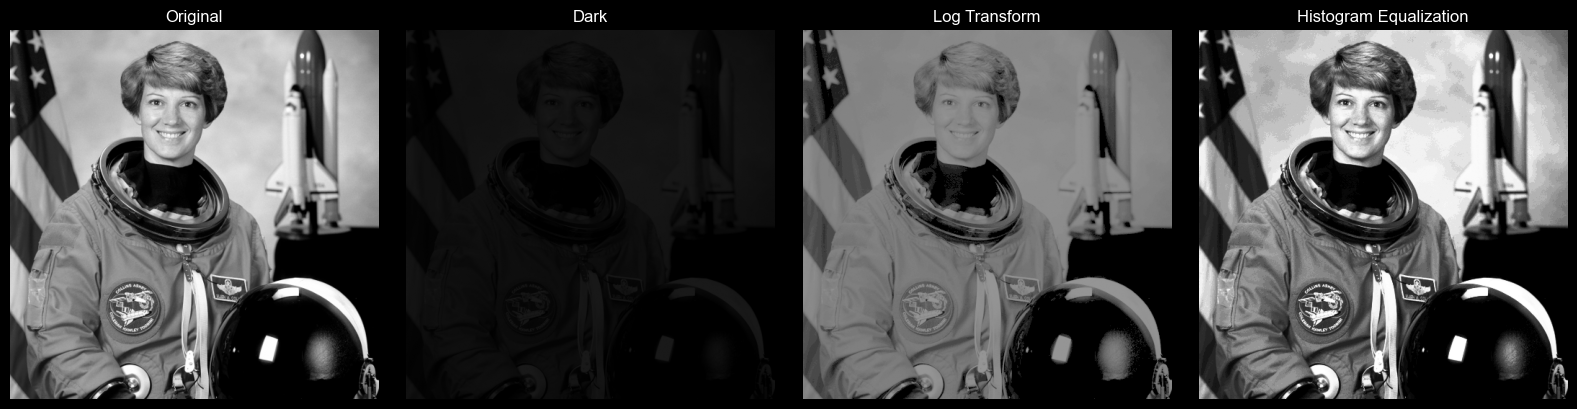

In [93]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(matriksblur, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gambar_dark, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Dark")
axes[1].axis("off")

hasil_log = log_transform(gambar_dark)

axes[2].imshow(hasil_log, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Log Transform")
axes[2].axis("off")

hasil_histogram = histogram_equalization(gambar_dark)
axes[3].imshow(hasil_histogram, cmap="gray", vmin=0, vmax=255)
axes[3].set_title("Histogram Equalization")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Bright Image Enhancement

In [94]:
gambar_bright = matriksblur.astype(float) * 1.5
gambar_bright = np.clip(gambar_bright, 0, 255).astype(np.uint8)

In [95]:
def gamma_transform(matriks, gamma):
    hasil = matriks.astype(float).copy()

    for i in range(len(matriks)):
        for j in range(len(matriks[i])):
            r = matriks[i][j]

            hasil[i][j] = 255 * ((r / 255) ** gamma)

    return np.clip(hasil, 0, 255).astype(np.uint8)

In [96]:
hasil_gamma = gamma_transform(gambar_bright, 2)

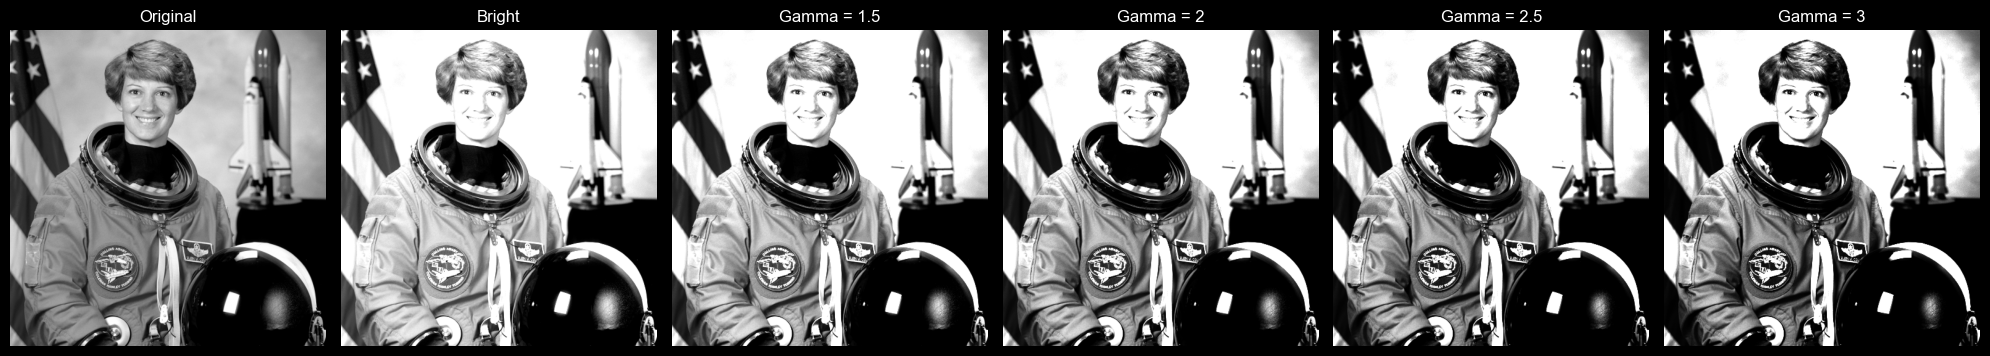

In [97]:
gamma = [1.5, 2, 2.5, 3]

fig, axes = plt.subplots(1, 6, figsize=(20, 4))

# Original
axes[0].imshow(matriksblur, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

# Bright
axes[1].imshow(gambar_bright, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Bright")
axes[1].axis("off")

# Gamma
for k in range(len(gamma)):
    hasil = gamma_transform(gambar_bright, gamma[k])

    axes[k + 2].imshow(hasil, cmap="gray", vmin=0, vmax=255)
    axes[k + 2].set_title(f"Gamma = {gamma[k]}")
    axes[k + 2].axis("off")

plt.tight_layout()
plt.show()

## Low Contrast Image Enhancement

In [98]:
gambar_low = matriksblur.astype(float)
gambar_low = 100 + (gambar_low / 255) * 80
gambar_low = np.clip(gambar_low, 0, 255).astype(np.uint8)

In [99]:
def contrast_stretching(matriks, batas_bawah, batas_atas):
    hasil = (matriks.astype(float) - batas_bawah) / (batas_atas - batas_bawah) * 255
    return np.clip(hasil, 0, 255).astype(np.uint8)

In [100]:
hasil1 = contrast_stretching(gambar_low, 90, 190)
hasil2 = contrast_stretching(gambar_low, 100, 180)
hasil3 = contrast_stretching(gambar_low, 110, 170)

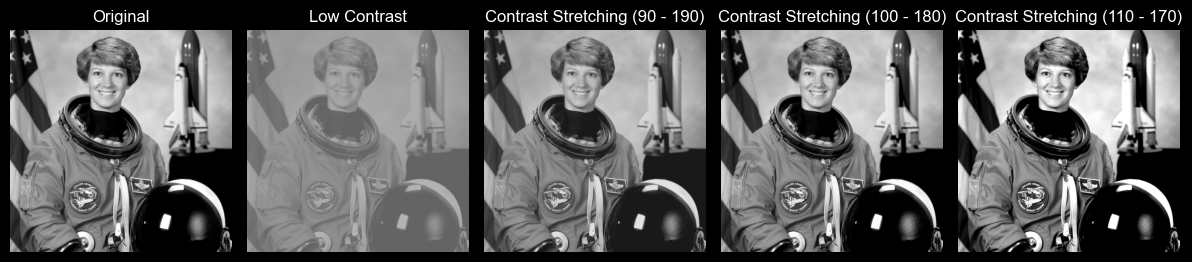

In [102]:
fig, axes = plt.subplots(1, 5, figsize=(12, 4))

axes[0].imshow(matriksblur, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gambar_low, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Low Contrast")
axes[1].axis("off")

axes[2].imshow(hasil1, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Contrast Stretching (90 - 190)")
axes[2].axis("off")

axes[3].imshow(hasil2, cmap="gray", vmin=0, vmax=255)
axes[3].set_title("Contrast Stretching (100 - 180)")
axes[3].axis("off")

axes[4].imshow(hasil3, cmap="gray", vmin=0, vmax=255)
axes[4].set_title("Contrast Stretching (110 - 170)")
axes[4].axis("off")

plt.tight_layout()
plt.show()